In [19]:
from pathlib import Path
import pandas as pd

# Hämta datan från filen och läser in den
file = Path.cwd().parent / 'data' / 'bronze'
parquet_file = Path.cwd().parent / 'data' / 'silver' / 'charts.parquet'

if parquet_file.exists():
    print("reading parquet file")
    df = pd.read_parquet(parquet_file)

else:
    print("No parquet file found")
    df = pd.read_csv(file /"charts.csv")

    # Ta bort kolumn för URL:er för ökad hastighet
    remove_url_column = ['url']
    df = df.drop(columns = remove_url_column)

    print("Creating parquet file")
    df.to_parquet(parquet_file)

reading parquet file


In [21]:
rows, cols = df.shape
print(f"rows: {rows}, columns: {cols}")

rows: 26173514, columns: 8


In [22]:
df.describe()

,rank,streams
count,2.617351e+07,2.032190e+07
mean,8.092314e+01,5.526131e+04
std,5.918601e+01,2.095872e+05
min,1.000000e+00,1.001000e+03
25%,2.900000e+01,3.546000e+03
50%,6.700000e+01,9.565000e+03
75%,1.310000e+02,3.540900e+04
max,2.000000e+02,1.974970e+07


In [23]:
df.columns

Index(['title', 'rank', 'date', 'artist', 'region', 'chart', 'trend',
       'streams'],
      dtype='str')

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26173514 entries, 0 to 26173513
Data columns (total 8 columns):
 #   Column   Dtype  
---  ------   -----  
 0   title    str    
 1   rank     int64  
 2   date     str    
 3   artist   str    
 4   region   str    
 5   chart    str    
 6   trend    str    
 7   streams  float64
dtypes: float64(1), int64(1), str(6)
memory usage: 3.1 GB


In [25]:
df["region"].value_counts().head(4)

region
Argentina        455308
United States    455057
Austria          454593
Brazil           454439
Name: count, dtype: int64

In [26]:
df["date"].value_counts().head(4)

date
2020-12-24    17022
2021-07-16    17009
2021-05-21    16997
2021-11-26    16974
Name: count, dtype: int64

In [27]:
df["trend"].value_counts().head(4)

trend
MOVE_DOWN        11220434
MOVE_UP           9801048
SAME_POSITION     3298392
NEW_ENTRY         1853640
Name: count, dtype: int64

In [28]:
df["rank"].value_counts().head(4)

rank
1    227253
5    227203
6    227201
4    227199
Name: count, dtype: int64

In [29]:
df["chart"].value_counts().head(4)

chart
top200     20321904
viral50     5851610
Name: count, dtype: int64

In [30]:
import duckdb

duckdb.sql("""--sql
SELECT *
FROM df
WHERE chart = 'viral50'
LIMIT 5
""").df()

,title,rank,date,artist,region,chart,trend,streams
0,Boys,13,2017-08-01,Charli XCX,Latvia,viral50,MOVE_UP,NaN
1,Hold Me,19,2017-08-01,R3HAB,Luxembourg,viral50,MOVE_DOWN,NaN
2,Hola Hola,40,2017-08-01,KARD,Peru,viral50,NEW_ENTRY,NaN
3,Cuídate,4,2017-08-01,Zetazen,Spain,viral50,SAME_POSITION,NaN
4,Boys,13,2017-08-01,Charli XCX,Taiwan,viral50,MOVE_DOWN,NaN


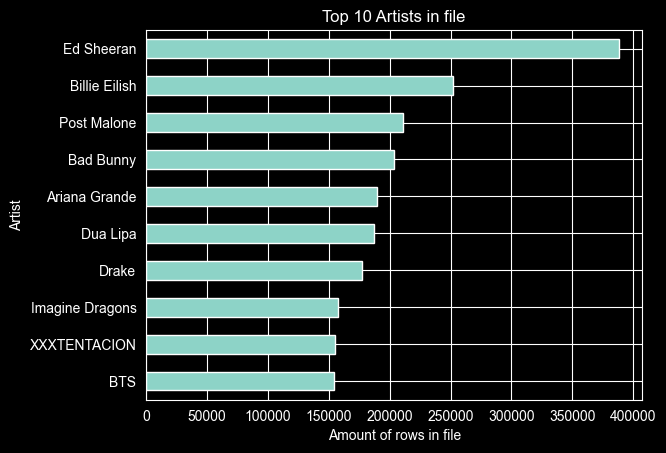

In [36]:
ax = (
    df["artist"]
    .value_counts()
    .head(10)
    .plot(
        kind="barh",
        title="Top 10 Artists in file",
        xlabel="Amount of rows in file",
        ylabel="Artist",
    )
)
ax.invert_yaxis()

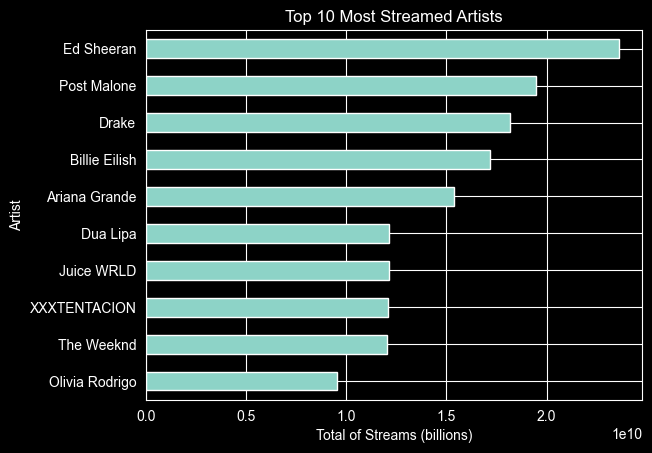

In [37]:
artist_streams = df.groupby("artist")["streams"].sum().sort_values(ascending = False).head(10)

ax = artist_streams.plot(
    kind="barh",
    title= "Top 10 Most Streamed Artists",
    xlabel="Total of Streams (billions)",
    ylabel= "Artist"
)

ax.invert_yaxis()

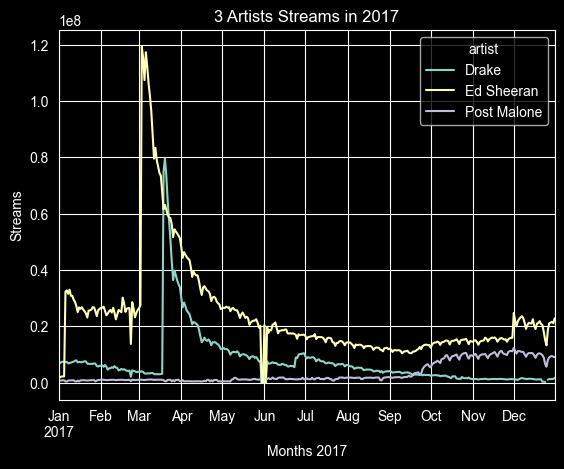

In [63]:
df['date'] = pd.to_datetime(df['date'])

artists  = ["Ed Sheeran", "Post Malone", "Drake"]
period = (df["date"] >= '2017-01-01') & (df["date"] <= '2017-12-31')
df_filtered = df[period & df["artist"].isin(artists)]

result = df_filtered.groupby(["artist", "date"])["streams"].sum()
# För att skapa egna linjer till artisterna
plot_data = result.unstack(level=0)
ax = plot_data.plot(
    kind="line",
    title= "3 Artists Streams in 2017",
    xlabel= "Months 2017",
    ylabel= "Streams",
    )
